# Travel date planning using historical data (2022-2025)

In this analysis, we will answer weather-related questions travelers may have when planning their trip dates. For instance:
- What time of year offers confortable daytime temperatures?
- When is it the least rainy?
- When am I likely to get the clearest skies for the best view from the top of Tokyo Skytree?
- At what time of year is the ropeway (cable car) up the mountain in Hakone / Miyajima / Kyoto most likely to be open?
- When can I see Kanazawa under the snow?

At the end, I will make travel date recommendations based on all these points per city.

## Definitions

We will consider confortable temperatures to be any day where
- the average daily minimum is above 0ºc.
- the average daily maximum is between 8 and 26ºc.

Clear sky = cloud_cover under 30% (already calculated in dbt model)

## Importing the weather data table

The ```mart_weather_monthly``` table contains monthly weather metrics computed from several years of historical hourly data.
For each city, it includes:
- average daytime temperatures
- rainfall totals and rain-free day ratio
- cloud-cover-based visibility metrics
- wind conditions (including ropeway-safe day ratios)
- snowfall totals and snow-event frequency (where relevant)
These monthly aggregates allow us to compare cities across seasons and identify the best travel windows.

Here we import the ```mart_weather_monthly``` view from BigQuery that we created:

In [5]:
from google.cloud import bigquery
import pandas as pd

# Establish connection to Bigquery project datasets and query the marts
client = bigquery.Client(project="weather-travel-recommendations")
query = """
SELECT *
FROM weather-travel-recommendations.weather_dbt_dev.mart_weather_monthly
ORDER BY city,year_month
"""

df_monthly_hist = client.query(query).to_dataframe()
df_monthly_hist.head()

/Users/rachel/Documents/portfolio/api-data-pipeline/.venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,city,month_start_date,year_month,days_in_month_with_data,avg_monthly_temp_c,min_daily_avg_temp_c,max_daily_avg_temp_c,ropeway_safe_days,ropeway_safe_days_ratio,rain_free_days,rain_free_days_ratio,snow_event_days,snow_event_days_ratio,avg_snow_intensity_mm,total_daytime_hours,total_daytime_clear_hours,daytime_clear_sky_hours_ratio
0,hakone_ropeway,2022-01-01,2022-01,31,-1.417070,-4.387500,1.812500,12,0.387097,16,0.516129,12,0.387097,1.277500,320,109,0.340625
1,hakone_ropeway,2022-02-01,2022-02,28,-2.447024,-7.466667,2.458333,6,0.214286,15,0.535714,12,0.428571,3.126667,308,126,0.409091
2,hakone_ropeway,2022-03-01,2022-03,31,4.879167,-0.437500,11.558333,5,0.161290,7,0.225806,7,0.225806,1.980000,366,69,0.188525
3,hakone_ropeway,2022-04-01,2022-04,30,9.360556,1.045833,16.245833,7,0.233333,9,0.300000,3,0.100000,2.613333,396,75,0.189394
4,hakone_ropeway,2022-05-01,2022-05,31,12.598387,6.491667,17.662500,11,0.354839,9,0.290323,0,0.000000,NaN,434,61,0.140553


In [19]:
df_monthly_hist[df_monthly_hist.city=="sapporo"]

,city,month_start_date,year_month,days_in_month_with_data,avg_monthly_temp_c,min_daily_avg_temp_c,max_daily_avg_temp_c,ropeway_safe_days,ropeway_safe_days_ratio,rain_free_days,rain_free_days_ratio,snow_event_days,snow_event_days_ratio,avg_snow_intensity_mm,total_daytime_hours,total_daytime_clear_hours,daytime_clear_sky_hours_ratio


In [24]:
import matplotlib.pyplot as plt

df = df_monthly_hist.copy()
df["comfortable"] = (
    (df["min_daily_avg_temp_c"] > 0) &
    (df["max_daily_avg_temp_c"].between(8, 26))
)

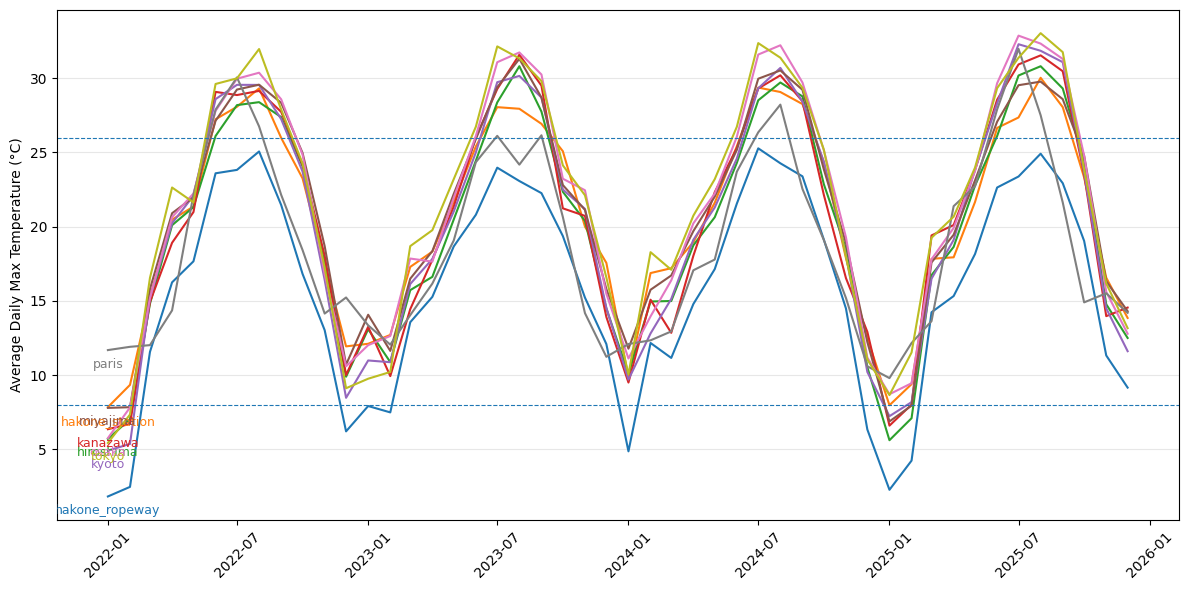

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for city, sub in df.groupby("city"):
    # Ensure months are in order
    sub = sub.sort_values("month_start_date")

    # Plot the line for this city
    line, = plt.plot(sub["month_start_date"], sub["max_daily_avg_temp_c"], label=city)

    # Get first point OUTSIDE the comfort zone
    outside_mask = ~sub["comfortable"]

    if outside_mask.any():
        first_outside = sub[outside_mask].iloc[0]

        x = first_outside["month_start_date"]
        y = first_outside["max_daily_avg_temp_c"]

        # Label just below that point, in the same colour as the line
        plt.text(
            x,
            y - 0.5,              # small vertical offset so it's clearly "below"
            city,
            color=line.get_color(),
            fontsize=9,
            ha="center",
            va="top",
            clip_on=True
        )
    else:
        # Fallback: if it's NEVER outside the threshold, label at last point
        last = sub.iloc[-1]
        x = last["month_start_date"]
        y = last["max_daily_avg_temp_c"]
        plt.text(
            x,
            y - 0.5,
            city,
            color=line.get_color(),
            fontsize=9,
            ha="center",
            va="top",
            clip_on=True
        )

# Comfort threshold lines
plt.axhline(8, linestyle="--", linewidth=0.8)
plt.axhline(26, linestyle="--", linewidth=0.8)

plt.ylabel("Average Daily Max Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

